# 10x Human Breast HierDecon Pipeline and Evaluation

This notebook runs the lean HierDecon pipeline on the 10x Genomics human breast Visium/Xenium dataset, exports the result in the shared benchmark schema, and compares it with external deconvolution methods.

## 1. Run HierDecon

In [9]:
from pathlib import Path
import sys

import pandas as pd

NotebookPath = Path.cwd().resolve()
RepoRoot = NotebookPath
while RepoRoot != RepoRoot.parent and not (RepoRoot / "hierdecon" / "__init__.py").exists():
    RepoRoot = RepoRoot.parent

if str(RepoRoot) not in sys.path:
    sys.path.insert(0, str(RepoRoot))

from hierdecon import loadhires, runpipeline
from hierdecon.benchmark import buildgroundtruth, clonefigure, detectiontables, exporthierdecon, necrosisfigure, readresult, runtimetable, scorefolder

In [2]:
SampleID = "10x_human_breast"
SpatialFolder = RepoRoot / "Janesick" / "Visium" / "spatial"
SpatialData = RepoRoot / "Janesick" / "Visium" / "CytAssist_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
TissuePositions = SpatialFolder / "tissue_positions.csv"
ScaleFactors = SpatialFolder / "scalefactors_json.json"
HiresImage = SpatialFolder / "tissue_hires_image.png"
GtfFile = RepoRoot / "data" / "gencode.v44.annotation.gtf.gz"

OutputFolder = RepoRoot / "hierdecon" / "outputs" / SampleID
BenchmarkFolder = OutputFolder / "benchmark"
OutputFolder.mkdir(parents=True, exist_ok=True)
BenchmarkFolder.mkdir(parents=True, exist_ok=True)

print("Repository root:", RepoRoot)

Repository root: /Users/bagel/Documents/Brown University/Courses/PHP2691/FinalProject2


In [3]:
adata = runpipeline(
    SpatialData,
    TissuePositions,
    ScaleFactors,
    SpatialFolder,
    HiresImage,
    GtfFile,
    SampleID=SampleID,
    ReferenceBeta=True,
    UseMarkerWeights=True,
)

/opt/anaconda3/envs/php2691/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
print("Spots:", adata.n_obs)
print("Genes:", adata.n_vars)
print("CNV subclones:", len(adata.uns["cnv_subclones"]))
print("HierDecon leaves:", len(adata.uns["leaf_names"]))
print("Reference beta columns:", len(adata.uns["beta_reference_names"]))

Spots: 4981
Genes: 18085
CNV subclones: 3
HierDecon leaves: 6
Reference beta columns: 13


In [5]:
ResultFile = exporthierdecon(
    adata,
    BenchmarkFolder / f"{SampleID}_hierdecon_refFree.npz",
    SampleID=SampleID,
    UseReferenceBeta=True,
    UseMarkerWeights=True,
)
ResultFile

PosixPath('/Users/bagel/Documents/Brown University/Courses/PHP2691/FinalProject2/hierdecon/outputs/10x_human_breast/benchmark/10x_human_breast_hierdecon_refFree.npz')

In [6]:
Image, HiresScale = loadhires(HiresImage, ScaleFactors)

### 1.1 CNV Clone Detection

Figures show the CNV magnitude and the inferred subclone labels.

,clone,spots
0,normal,3237
1,tumor_subclone_2,1069
2,tumor_subclone_0,469
3,tumor_subclone_1,206


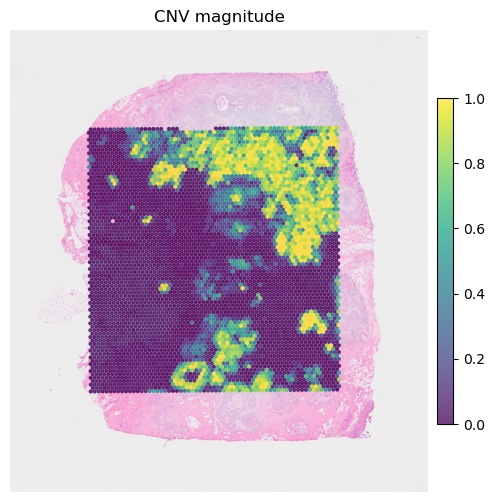

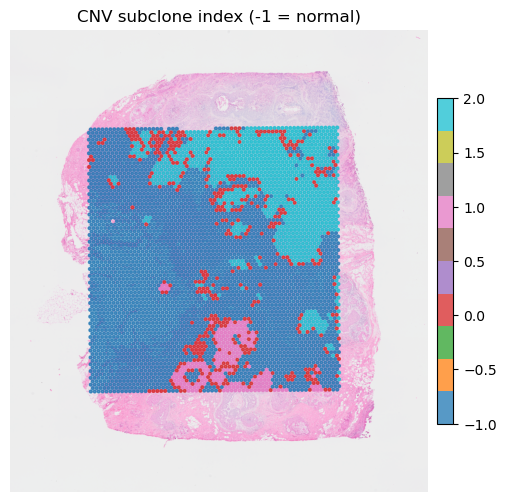

In [10]:
CloneCounts, CloneScores = clonefigure(adata, Image, HiresScale)
CloneCounts

In [8]:
CloneScores

,k,silhouette
0,2,0.177479
1,3,0.190451
2,4,0.124171
3,5,0.090912
4,6,0.080165
5,7,0.070209
6,8,0.062989
7,9,0.054464
8,10,0.049226


### 1.2 Necrosis Post Hoc Diagnostic

Diagnostic for necrosis spots post deconvolution

,threshold,flagged_spots,total_spots,flagged_in_gt_mask,flagged_out_gt_mask,mean_tumor_flagged,mean_tumor_other
0,1.582453,250,4981,88,162,0.120716,0.289696


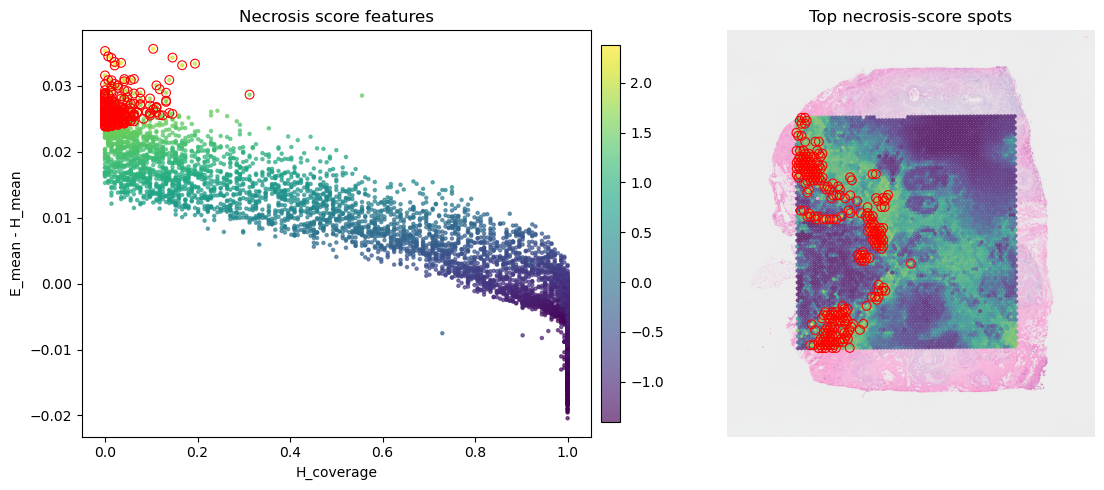

In [ ]:
NecrosisSummary = necrosisfigure(adata, Image, HiresScale, GroundTruth)
NecrosisSummary

## 2. Benchmark Evaluation

### 2.1 Build Xenium Ground Truth

This uses the official 10x Xenium-to-Visium registration logic from the existing evaluation code.

In [11]:
DataFolder = RepoRoot / "Janesick"
GroundTruth = buildgroundtruth(adata, DataFolder)

print("Ground truth spots:", GroundTruth["Y_super"].shape[0])
print("Ground truth supertypes:", GroundTruth["Y_super"].shape[1])
print("Ground truth subtypes:", GroundTruth["Y_subtype"].shape[1])

Ground truth spots: 4981
Ground truth supertypes: 4
Ground truth subtypes: 13


### 2.2 Score Available Method Outputs

In [12]:
Manifest, Scores = scorefolder(adata, BenchmarkFolder, GroundTruth)
Manifest

,path,method,ref_tag,sample_id,n_spots,has_beta
0,/Users/bagel/Documents/Brown University/Course...,hierdecon,refFree,10x_human_breast,4981,True
1,/Users/bagel/Documents/Brown University/Course...,spacet,builtin_BRCA,janesick_visium_R1,4981,True
2,/Users/bagel/Documents/Brown University/Course...,spacet,matched_wu,janesick_visium_R1,4981,True
3,/Users/bagel/Documents/Brown University/Course...,starfysh,signatures,janesick_visium_R1,4981,True
4,/Users/bagel/Documents/Brown University/Course...,stdeconvolve,refFree,janesick_visium_R1,4981,True


,threshold,flagged_spots,total_spots,flagged_in_gt_mask,flagged_out_gt_mask,mean_tumor_flagged,mean_tumor_other
0,1.582453,250,4981,88,162,0.120716,0.289696


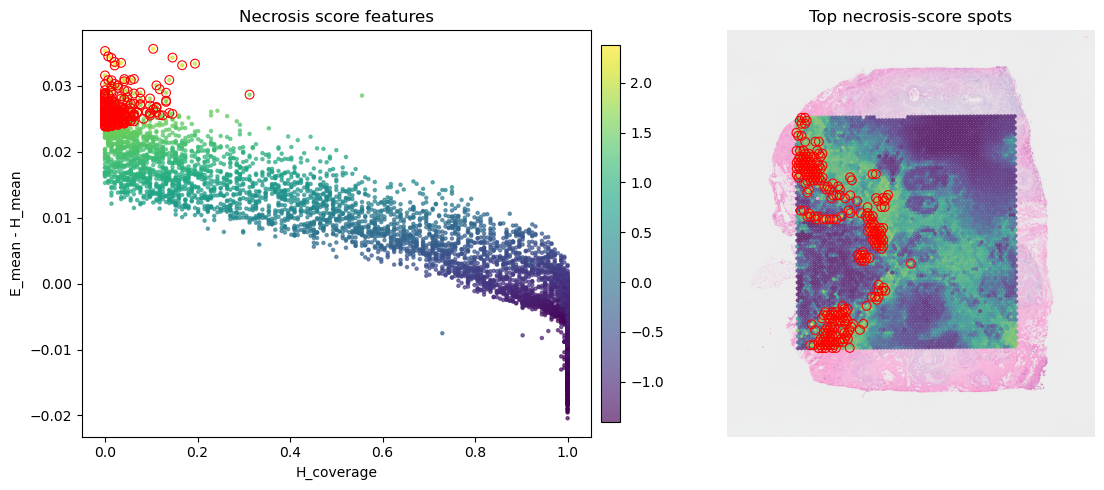

In [15]:
NecrosisSummary = necrosisfigure(adata, Image, HiresScale, GroundTruth)
NecrosisSummary

### 2.3 Summary Metric Tables

Each table averages across cell types for one metric. RMSE is better when lower; PCC is better when higher.

In [16]:
EvaluationFolder = OutputFolder / "evaluation"
EvaluationFolder.mkdir(parents=True, exist_ok=True)

for Name, Table in Scores.items():
    Table.to_csv(EvaluationFolder / f"{Name}.csv", index=False)

PiDetection, BetaDetection = detectiontables(adata, Manifest, GroundTruth)
PiDetection.to_csv(EvaluationFolder / "pi_detection.csv", index=False)
BetaDetection.to_csv(EvaluationFolder / "beta_detection.csv", index=False)


def metricsummary(Table, ValueColumn, Ascending):
    Summary = Table.groupby("method", as_index=False)[ValueColumn].mean()
    Summary = Summary.sort_values(ValueColumn, ascending=Ascending)
    Summary[ValueColumn] = Summary[ValueColumn].round(3)
    return Summary


PiRmseSummary = metricsummary(Scores["pi_rmse"], "rmse", True)
PiPccSummary = metricsummary(Scores["pi_pcc"], "pcc", False)
PiAuprcSummary = metricsummary(PiDetection, "auprc", False)
PiAurocSummary = metricsummary(PiDetection, "auroc", False)
BetaRmseSummary = metricsummary(Scores["beta_rmse"], "rmse", True)
BetaPccSummary = metricsummary(Scores["beta_pcc"], "pcc", False)
BetaAuprcSummary = metricsummary(BetaDetection, "auprc", False)
BetaAurocSummary = metricsummary(BetaDetection, "auroc", False)

for Name, Table in {
    "pi_rmse_summary": PiRmseSummary,
    "pi_pcc_summary": PiPccSummary,
    "pi_auprc_summary": PiAuprcSummary,
    "pi_auroc_summary": PiAurocSummary,
    "beta_rmse_summary": BetaRmseSummary,
    "beta_pcc_summary": BetaPccSummary,
    "beta_auprc_summary": BetaAuprcSummary,
    "beta_auroc_summary": BetaAurocSummary,
}.items():
    Table.to_csv(EvaluationFolder / f"{Name}.csv", index=False)

In [17]:
PiRmseSummary

,method,rmse
0,hierdecon@refFree,0.165
2,spacet@matched_wu,0.172
1,spacet@builtin_BRCA,0.209
3,starfysh@signatures,0.392
4,stdeconvolve@refFree,0.415


In [18]:
PiPccSummary

,method,pcc
2,spacet@matched_wu,0.795
1,spacet@builtin_BRCA,0.772
0,hierdecon@refFree,0.747
4,stdeconvolve@refFree,0.408
3,starfysh@signatures,0.269


In [19]:
BetaRmseSummary

,method,rmse
0,hierdecon@refFree,0.105
2,spacet@matched_wu,0.123
1,spacet@builtin_BRCA,0.144
3,starfysh@signatures,0.206
4,stdeconvolve@refFree,0.273


In [20]:
BetaPccSummary

,method,pcc
0,hierdecon@refFree,0.550
2,spacet@matched_wu,0.467
1,spacet@builtin_BRCA,0.318
4,stdeconvolve@refFree,0.189
3,starfysh@signatures,0.172


### 2.4 Detection Metric Tables

AUPRC and AUROC treat each cell type as a one-vs-rest detection task. A spot is positive when the Xenium ground truth abundance for that cell type is greater than zero.

In [21]:
PiAuprcSummary

,method,auprc
2,spacet@matched_wu,0.900
0,hierdecon@refFree,0.897
1,spacet@builtin_BRCA,0.726
4,stdeconvolve@refFree,0.706
3,starfysh@signatures,0.644


In [22]:
PiAurocSummary

,method,auroc
2,spacet@matched_wu,0.860
0,hierdecon@refFree,0.845
1,spacet@builtin_BRCA,0.709
3,starfysh@signatures,0.629
4,stdeconvolve@refFree,0.588


In [23]:
BetaAuprcSummary

,method,auprc
0,hierdecon@refFree,0.629
2,spacet@matched_wu,0.538
3,starfysh@signatures,0.474
1,spacet@builtin_BRCA,0.472
4,stdeconvolve@refFree,0.408


In [24]:
BetaAurocSummary

,method,auroc
0,hierdecon@refFree,0.775
2,spacet@matched_wu,0.688
1,spacet@builtin_BRCA,0.647
3,starfysh@signatures,0.603
4,stdeconvolve@refFree,0.501


### 2.4 Per-Cell-Type Metric Tables

These tables show π metrics for each supertype and β metrics for each subtype across all available methods.

In [25]:
def metrictable(Table, Name, ValueColumn):
    Pivot = Table.pivot(index="celltype", columns="method", values=ValueColumn)
    Pivot = Pivot.round(3)
    Pivot.to_csv(EvaluationFolder / f"{Name}_by_celltype.csv")
    return Pivot


PiRmseByCelltype = metrictable(Scores["pi_rmse"], "pi_rmse", "rmse")
PiPccByCelltype = metrictable(Scores["pi_pcc"], "pi_pcc", "pcc")
PiAuprcByCelltype = metrictable(PiDetection, "pi_auprc", "auprc")
PiAurocByCelltype = metrictable(PiDetection, "pi_auroc", "auroc")
BetaRmseBySubtype = metrictable(Scores["beta_rmse"], "beta_rmse", "rmse")
BetaPccBySubtype = metrictable(Scores["beta_pcc"], "beta_pcc", "pcc")
BetaAuprcBySubtype = metrictable(BetaDetection, "beta_auprc", "auprc")
BetaAurocBySubtype = metrictable(BetaDetection, "beta_auroc", "auroc")

#### π RMSE by Supertype

In [26]:
PiRmseByCelltype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
immune,0.176,0.192,0.171,0.354,0.402
normal_epi,0.073,0.107,0.072,0.361,0.241
stromal,0.250,0.286,0.233,0.456,0.662
tumor,0.162,0.250,0.212,0.398,0.355


#### π PCC by Supertype

In [27]:
PiPccByCelltype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
immune,0.491,0.511,0.608,0.505,0.365
normal_epi,0.751,NaN,0.797,-0.058,0.213
stromal,0.823,0.894,0.821,0.756,NaN
tumor,0.924,0.911,0.953,-0.126,0.646


#### β RMSE by Subtype

In [28]:
BetaRmseBySubtype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
B_cell,0.057,0.096,0.063,0.093,0.068
CAF,0.256,0.313,0.256,0.573,0.659
NK,0.003,NaN,NaN,NaN,NaN
T_cell,0.106,0.148,0.108,0.185,0.163
basal_normal,0.078,0.204,0.186,0.352,0.237
endothelial,0.097,0.139,0.129,0.144,0.165
luminal_normal,0.062,0.000,0.147,0.156,0.420
mast,0.015,0.057,0.014,0.073,0.207
myeloid,0.105,0.304,0.181,0.217,0.229


#### β PCC by Subtype

In [29]:
BetaPccBySubtype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
B_cell,0.487,0.133,0.182,0.442,NaN
CAF,0.803,0.607,0.736,0.438,NaN
NK,NaN,NaN,NaN,NaN,NaN
T_cell,0.745,0.425,0.699,0.506,0.495
basal_normal,0.700,NaN,0.511,-0.148,0.071
endothelial,0.576,0.414,0.557,0.090,NaN
luminal_normal,NaN,NaN,NaN,NaN,NaN
mast,0.072,-0.006,NaN,0.058,0.003
myeloid,0.285,0.334,0.251,-0.209,NaN


### 2.5 Mean Predicted Fractions

Follow tables show the average predicted π / β value for each method.

#### π AUPRC by Supertype

In [30]:
PiAuprcByCelltype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
immune,0.747,0.739,0.795,0.794,0.741
normal_epi,0.868,0.188,0.838,0.234,0.298
stromal,0.995,0.990,0.996,0.985,0.936
tumor,0.979,0.986,0.973,0.562,0.850


#### π AUROC by Supertype

In [31]:
PiAurocByCelltype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
immune,0.491,0.474,0.572,0.541,0.465
normal_epi,0.949,0.500,0.934,0.648,0.548
stromal,0.961,0.876,0.964,0.903,0.500
tumor,0.980,0.986,0.969,0.426,0.840


#### β AUPRC by Subtype

In [32]:
BetaAuprcBySubtype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
B_cell,0.633,0.411,0.406,0.609,0.296
CAF,0.993,0.986,0.992,0.981,0.929
NK,NaN,NaN,NaN,NaN,NaN
T_cell,0.660,0.614,0.703,0.640,0.548
basal_normal,0.723,0.188,0.557,0.172,0.212
endothelial,0.727,0.728,0.688,0.565,0.500
luminal_normal,NaN,NaN,NaN,NaN,NaN
mast,0.070,0.043,0.030,0.046,0.029
myeloid,0.652,0.714,0.669,0.601,0.653


#### β AUROC by Subtype

In [33]:
BetaAurocBySubtype

method,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,
B_cell,0.782,0.675,0.550,0.759,0.500
CAF,0.939,0.875,0.924,0.877,0.500
NK,NaN,NaN,NaN,NaN,NaN
T_cell,0.685,0.714,0.751,0.669,0.616
basal_normal,0.906,0.500,0.830,0.466,0.438
endothelial,0.747,0.685,0.717,0.521,0.500
luminal_normal,NaN,NaN,NaN,NaN,NaN
mast,0.725,0.646,0.500,0.614,0.458
myeloid,0.475,0.578,0.515,0.395,0.500


In [34]:
from hierdecon.benchmark import meanfractiontables

PiMeanTable, BetaMeanTable = meanfractiontables(Manifest, GroundTruth)
PiMeanTable.to_csv(EvaluationFolder / "mean_pi_by_celltype.csv")
BetaMeanTable.to_csv(EvaluationFolder / "mean_beta_by_subtype.csv")

#### Mean π by Supertype

In [35]:
PiMeanTable

method,ground_truth,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
celltype,,,,,,
immune,0.159,0.172,0.218,0.226,0.452,0.392
normal_epi,0.036,0.066,0.000,0.070,0.247,0.149
stromal,0.555,0.442,0.331,0.559,0.189,0.000
tumor,0.250,0.321,0.451,0.146,0.112,0.458


#### Mean β by Subtype

In [36]:
BetaMeanTable

method,ground_truth,hierdecon@refFree,spacet@builtin_BRCA,spacet@matched_wu,starfysh@signatures,stdeconvolve@refFree
subtype,,,,,,
B_cell,0.026,0.005,0.039,0.018,0.078,0.000
CAF,0.491,0.383,0.414,0.451,0.085,0.000
NK,0.000,0.001,NaN,NaN,NaN,NaN
T_cell,0.053,0.008,0.088,0.035,0.188,0.094
basal_normal,0.036,0.022,0.000,0.016,0.177,0.080
endothelial,0.059,0.015,0.080,0.151,0.064,0.000
luminal_normal,0.000,0.043,0.000,0.082,0.096,0.216
mast,0.001,0.002,0.015,0.000,0.057,0.066
myeloid,0.079,0.048,0.313,0.144,0.080,0.000
